# IR Protocol

**Goal**: Decode the raw IR signals of a Voltas Air Conditioner to build a custom ESPHome component.

In [1]:
import json
import matplotlib.pyplot as plt

## Load Data

The raw pronto hex codes are stored in a json file. A Pronto Hex Code contains:
*   **Header:** The first 4 words define the signal type, frequency, and burst lengths. We will drop these.
*   **Footer/Stop Bit:** The final 2 words usually represent the very last Mark and a massive trailing Space (e.g., `0180`).
* Alternating pairs of hexadecimal words representing the duration of the IR pulses (Marks) and gaps (Spaces)

In [2]:
raw_pronto_codes_file = "./pronto-code/raw-pronto-codes.json"

In [3]:
raw_pronto_codes = []
with open(raw_pronto_codes_file, 'r') as file:
    raw_pronto_codes = json.load(file)

print(f"Loaded {len(raw_pronto_codes)} pronto hex codes from {raw_pronto_codes_file}")
raw_pronto_codes[:5]

Loaded 29 pronto hex codes from ./pronto-code/raw-pronto-codes.json


[{'hex': '0000 006D 0051 0000 0029 0016 0028 0016 0028 0063 002A 0061 0028 0016 0028 0015 0029 0063 0028 0063 0028 0063 0028 0063 0028 0063 0029 0014 0029 0063 0028 0016 0029 0014 0029 0016 0028 0062 0028 0016 0028 0016 0028 0016 0028 0016 0028 0016 0029 0015 0028 0015 0029 0016 0027 0017 0029 0015 0028 0063 0028 0016 0029 0015 0029 0015 0028 0063 0029 0015 0029 0015 0028 0063 0028 0063 0029 0062 0028 0016 0028 0063 0028 0063 0028 0016 0028 0016 0028 0062 0028 0063 002A 0061 0028 0016 0028 0063 0028 0063 0028 0016 0028 0016 0028 0063 0028 0064 002A 005F 0028 0016 0028 0063 0027 0064 0027 0017 0028 0016 0028 0015 0029 0063 0029 0015 0028 0016 0028 0016 0029 0062 0028 0016 0028 0016 0029 0015 0028 0063 0028 0016 0028 0016 0028 0016 0029 0015 0028 0063 0028 0016 0029 0015 0028 0016 0028 0016 0028 0017 0027 0016 0028 0063 0028 0180\r\n',
  'label': '17-cool-fan-auto'},
 {'hex': '0000 006D 0051 0000 0028 0015 0029 0016 0028 0062 002A 0062 0028 0016 0028 0016 0028 0063 0029 0062 0028 0016 00

In [4]:
labels = set([code['label'] for code in raw_pronto_codes])
labels

{'17-cool-fan-auto',
 '17-cool-fan-high',
 '17-cool-fan-low',
 '17-cool-fan-medium',
 '17-cool-hswing-off',
 '17-cool-hswing-on',
 '17-cool-turbo-off',
 '17-cool-turbo-on',
 '17-cool-vswing-off',
 '17-cool-vswing-on',
 '24-to-23-sun-fan-high',
 '24-to-25-cool-fan-high',
 '25-to-24-cool-fan-high',
 '25-to-26-cool-fan-high',
 '26-to-25-cool-fan-high',
 '26-to-27-cool-fan-high',
 '27-to-26-cool-fan-high',
 '28-cool-fan-high',
 '28-to-24-drop-fan-low',
 'lamp-off',
 'lamp-on',
 'mode-fan-high',
 'mode-fan-low',
 'mode-fan-medium',
 'off',
 'off-17-cool',
 'off-28',
 'on',
 'on-28'}

## Processing

First, let's convert the raw hex values into decimals so that we can do some basic analysis using numbers

In [5]:
pronto_codes = []
for code in raw_pronto_codes:
    pronto_code = code
    pronto_code['raw'] = code['hex']
    pronto_code['hex'] = code['hex'].split()
    pronto_code["dec"] = [int(x, 16) for x in pronto_code['hex']]
    pronto_codes.append(pronto_code)

In [6]:
idx = 0
_code = pronto_codes[idx]
print(f"idx: {idx}\n\n")
print(f"hex: {_code['raw']}")
print(f"decimals: {" ".join([str(x) for x in _code['dec']])}\n\n")
print(f"len(hex): {len(_code['hex'])}")
print(f"len(dec): {len(_code['dec'])}")

idx: 0


hex: 0000 006D 0051 0000 0029 0016 0028 0016 0028 0063 002A 0061 0028 0016 0028 0015 0029 0063 0028 0063 0028 0063 0028 0063 0028 0063 0029 0014 0029 0063 0028 0016 0029 0014 0029 0016 0028 0062 0028 0016 0028 0016 0028 0016 0028 0016 0028 0016 0029 0015 0028 0015 0029 0016 0027 0017 0029 0015 0028 0063 0028 0016 0029 0015 0029 0015 0028 0063 0029 0015 0029 0015 0028 0063 0028 0063 0029 0062 0028 0016 0028 0063 0028 0063 0028 0016 0028 0016 0028 0062 0028 0063 002A 0061 0028 0016 0028 0063 0028 0063 0028 0016 0028 0016 0028 0063 0028 0064 002A 005F 0028 0016 0028 0063 0027 0064 0027 0017 0028 0016 0028 0015 0029 0063 0029 0015 0028 0016 0028 0016 0029 0062 0028 0016 0028 0016 0029 0015 0028 0063 0028 0016 0028 0016 0028 0016 0029 0015 0028 0063 0028 0016 0029 0015 0028 0016 0028 0016 0028 0017 0027 0016 0028 0063 0028 0180

decimals: 0 109 81 0 41 22 40 22 40 99 42 97 40 22 40 21 41 99 40 99 40 99 40 99 40 99 41 20 41 99 40 22 41 20 41 22 40 98 40 22 40 22 40 22 40 22 40 22 41

## Clusters / Frequency Distribution

Visually inspecting the numbers, we can identify some repeating patters. The numbers `21`, `22`, `40`, `41`, `98`, `99` (hex: `0028`, `0029`, `0014`, `0015`, `0062` etc) appear quite frequently. 

Let's start by analysing the frequency distribution to better understand the clutering of numbers.

In [7]:
from collections import Counter


In [8]:
all_hex_codes = []
all_dec_codes = []
for code in pronto_codes:
    all_hex_codes.extend(code["hex"])
    all_dec_codes.extend(code["dec"])

In [9]:
hex_counts = Counter(all_hex_codes)
hex_counts

Counter({'0028': 1103,
         '0016': 673,
         '0029': 590,
         '002A': 473,
         '0063': 404,
         '0015': 363,
         '0014': 245,
         '0062': 221,
         '0060': 126,
         '0027': 103,
         '0061': 79,
         '0017': 69,
         '0013': 63,
         '0000': 58,
         '002B': 51,
         '0064': 30,
         '006D': 29,
         '0051': 29,
         '0180': 29,
         '0026': 20,
         '005F': 17,
         '0018': 16,
         '0025': 5,
         '0012': 5,
         '0065': 3,
         '0019': 3,
         '002D': 2,
         '005D': 1,
         '0066': 1,
         '0024': 1,
         '002C': 1,
         '005E': 1})

In [10]:
dec_counts = Counter(all_dec_codes)
dec_counts

Counter({40: 1103,
         22: 673,
         41: 590,
         42: 473,
         99: 404,
         21: 363,
         20: 245,
         98: 221,
         96: 126,
         39: 103,
         97: 79,
         23: 69,
         19: 63,
         0: 58,
         43: 51,
         100: 30,
         109: 29,
         81: 29,
         384: 29,
         38: 20,
         95: 17,
         24: 16,
         37: 5,
         18: 5,
         101: 3,
         25: 3,
         45: 2,
         93: 1,
         102: 1,
         36: 1,
         44: 1,
         94: 1})

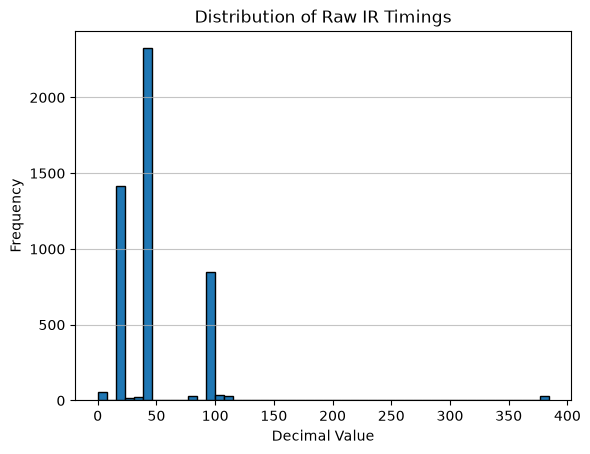

In [11]:
plt.hist(all_dec_codes, bins=50, edgecolor='black')
plt.title("Distribution of Raw IR Timings")
plt.xlabel("Decimal Value")
plt.ylabel("Frequency")
plt.grid(axis='y', alpha=0.75)
plt.show()

We can observe some clustering around `20`, `40`, `100`. The **header** and **footer** are causing the outliers (the massive spike at the end and 0 at the start).

C:\Users\shres\AppData\Local\Temp\ipykernel_87444\462284032.py:12: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


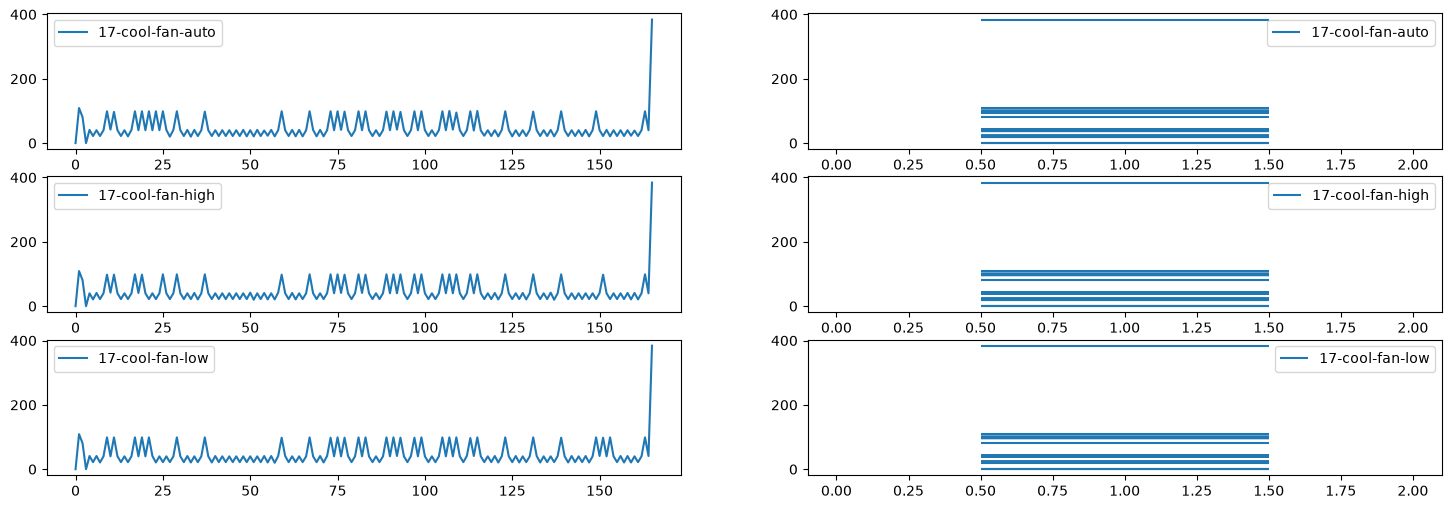

In [12]:
idx_selection = [0, 1, 2]

fig, axes = plt.subplots(len(idx_selection), 2, figsize=(18, 6))

for idx in idx_selection:
    decimal_values = pronto_codes[idx]['dec']
    axes[idx][0].plot(decimal_values, label=pronto_codes[idx]['label'])
    axes[idx][1].eventplot(decimal_values, orientation='vertical', label=pronto_codes[idx]['label'])
    axes[idx][0].legend()
    axes[idx][1].legend()

fig.show()

Let's remove the first 4 words (header) and the last 2 words (footer) from the pronto-codes. This will leave us with 160 datapoints.

In [13]:
# Remove the header and footer
for code in pronto_codes:
    code['hex'] = code['hex'][4:-2]
    code['dec'] = code['dec'][4:-2]

In [14]:
print(f"len(hex): {len(pronto_codes[0]['hex'])}")
print(f"len(dec): {len(pronto_codes[0]['dec'])}")

len(hex): 160
len(dec): 160


Let redo the frequency distribution analysis

In [15]:
all_hex_codes = []
all_dec_codes = []
for code in pronto_codes:
    all_hex_codes.extend(code["hex"])
    all_dec_codes.extend(code["dec"])



In [16]:
hex_counts = Counter(all_hex_codes)
hex_counts

Counter({'0028': 1087,
         '0016': 673,
         '0029': 583,
         '002A': 470,
         '0063': 404,
         '0015': 363,
         '0014': 245,
         '0062': 221,
         '0060': 126,
         '0027': 101,
         '0061': 79,
         '0017': 69,
         '0013': 63,
         '002B': 51,
         '0064': 30,
         '0026': 19,
         '005F': 17,
         '0018': 16,
         '0025': 5,
         '0012': 5,
         '0065': 3,
         '0019': 3,
         '002D': 2,
         '005D': 1,
         '0066': 1,
         '0024': 1,
         '002C': 1,
         '005E': 1})

In [17]:
dec_counts = Counter(all_dec_codes)
dec_counts

Counter({40: 1087,
         22: 673,
         41: 583,
         42: 470,
         99: 404,
         21: 363,
         20: 245,
         98: 221,
         96: 126,
         39: 101,
         97: 79,
         23: 69,
         19: 63,
         43: 51,
         100: 30,
         38: 19,
         95: 17,
         24: 16,
         37: 5,
         18: 5,
         101: 3,
         25: 3,
         45: 2,
         93: 1,
         102: 1,
         36: 1,
         44: 1,
         94: 1})

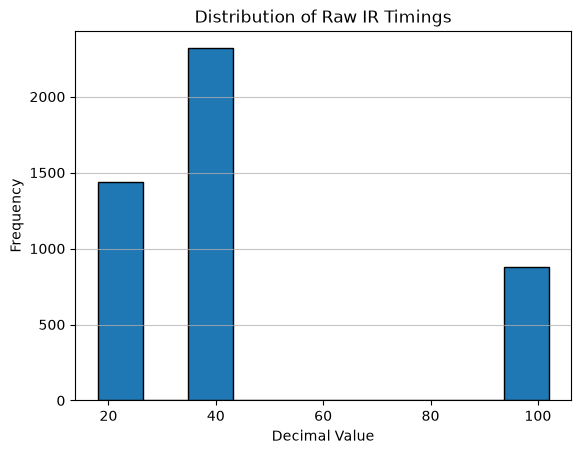

In [18]:
plt.hist(all_dec_codes, bins=10, edgecolor='black')
plt.title("Distribution of Raw IR Timings")
plt.xlabel("Decimal Value")
plt.ylabel("Frequency")
plt.grid(axis='y', alpha=0.75)
plt.show()

C:\Users\shres\AppData\Local\Temp\ipykernel_87444\137265684.py:16: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


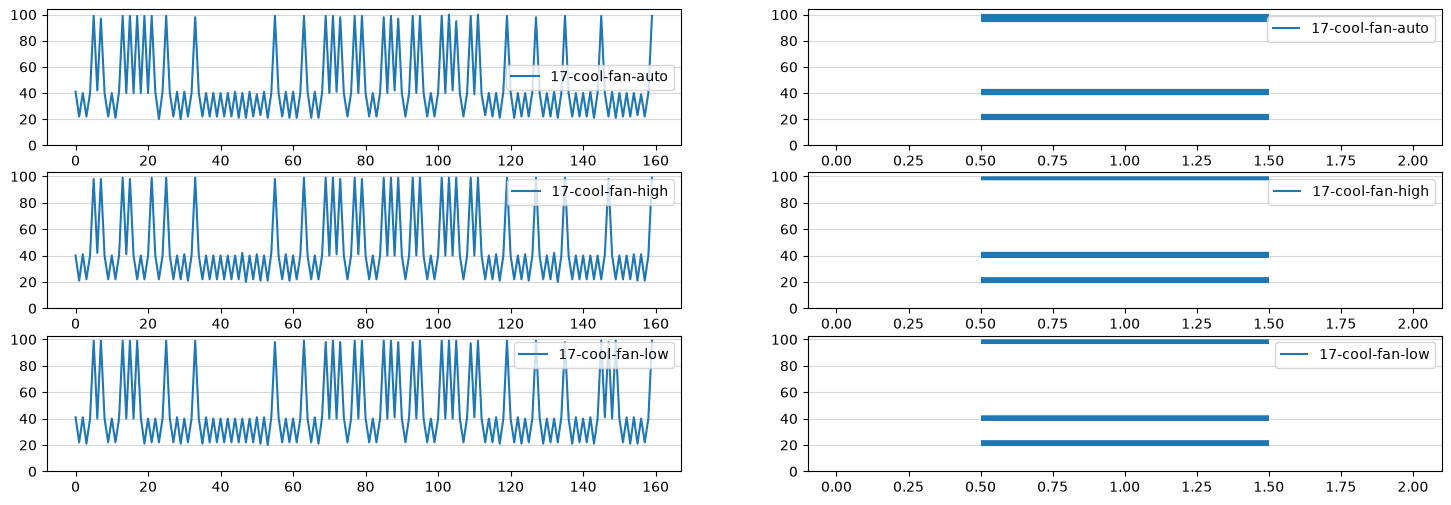

In [19]:
idx_selection = [0, 1, 2]

fig, axes = plt.subplots(len(idx_selection), 2, figsize=(18, 6))

for idx in idx_selection:
    decimal_values = pronto_codes[idx]['dec']
    axes[idx][0].plot(decimal_values, label=pronto_codes[idx]['label'])
    axes[idx][1].eventplot(decimal_values, orientation='vertical', label=pronto_codes[idx]['label'])
    axes[idx][0].legend()
    axes[idx][1].legend()
    axes[idx][0].set_yticks(range(0, 120, 20))
    axes[idx][1].set_yticks(range(0, 120, 20))
    axes[idx][0].grid(axis='y', alpha=0.5)
    axes[idx][1].grid(axis='y', alpha=0.5)

fig.show()

Much better. We can clearly see 3 bands clustered around `22`, `42` and `98`.

### Clustering the Frequencies

Visual inspection of the histogram reveals three distinct clusters. This aligns perfectly with how **Pulse Distance Modulation (PDM)** works in IR protocols:
1. A constant **Mark** (IR LED on).
2. A short **Space** representing a binary `0`.
3. A long **Space** representing a binary `1`.

In [20]:
import random

In [21]:
def kmeans(data: list[int], k: int = 3, max_iterations: int = 1000):
    """K-Means clustering implementation"""

    # Pick k unique random points as the starting centroids
    unique_data = list(set(data))

    # If we don't have enough points, just return what we have
    if len(unique_data) < k:
        return sorted(unique_data), {c: [c] for c in unique_data}

    # Pick k centroid randomly from the dataset
    centroids = random.sample(unique_data, k)

    clusters = {}
    for _ in range(max_iterations):
        # Create empty buckets for this iteration
        clusters = {c: [] for c in centroids}

        # Assign each data point to the closest centroid
        for point in data:
            nearest_centroid = min(centroids, key=lambda c: abs(c - point))
            clusters[nearest_centroid].append(point)

        # Calculate the new mean for each cluster
        new_centroids = []
        for c in centroids:
            if clusters[c]: # Avoid division by 0
                new_mean = sum(clusters[c]) / len(clusters[c])
                new_centroids.append(new_mean)
            else:
                new_centroids.append(c)

        # Convergence: Stop if centroids haven't moved
        if set(centroids) == set(new_centroids):
            break

        # Update the centroids for the next iteration
        centroids = new_centroids

    # Sort centroids so they are always ordered lowest to highest
    centroids.sort()

    # Re-key the clusters dictionary with the sorted centroids
    sorted_clusters = {c: clusters[c] for c in centroids}

    return [c for c in centroids], sorted_clusters

In [22]:
centroids, clusters = kmeans(all_dec_codes, k = 3)

print(f"Discovered Centroids: {centroids}\n")
for c in centroids:
    min_val = min(clusters[c])
    max_val = max(clusters[c])
    count = len(clusters[c])
    print(f"Center {round(c)} ({hex(round(c))}) | Count: {count:>4} | Range: {min_val} ({hex(min_val)}) to {max_val} ({hex(max_val)})")

Discovered Centroids: [21.3375086986778, 40.66034482758621, 98.09739524348811]

Center 21 (0x15) | Count: 1437 | Range: 18 (0x12) to 25 (0x19)
Center 41 (0x29) | Count: 2320 | Range: 36 (0x24) to 45 (0x2d)
Center 98 (0x62) | Count:  883 | Range: 93 (0x5d) to 102 (0x66)


The IR Protocol follows **Pulse Distance Modulation** and has an alternating Mark-Space sequence. Here we can observe that `41` appears 640 times which is the sum of `400` (for `21`) and `240` (for `98`). Since these datapoints are in pairs, `41` is the mark value while `21` (short-space) and `98` (long-space) would signify the bits.

## Binarization

Lets work under the assumption that `21` (short-space) represents the bit `0` and `98` (long-space) represents the bit `1`

In [23]:
# Calculate the thresholds using the centroids
midpoint_low = (centroids[0] + centroids[1]) / 2
midpoint_high = (centroids[1] + centroids[2]) / 2

print(f"Threshold for 0 (Short Space): < {midpoint_low:.2f}")
print(f"Threshold for 1 (Long Space): > {midpoint_high:.2f}\n")

Threshold for 0 (Short Space): < 31.00
Threshold for 1 (Long Space): > 69.38



In [24]:
for code in pronto_codes:
    bits = []

    # Extract the payload
    payload = code['dec']

    for val in payload:
        if val < midpoint_low:
            bits.append(0)
        elif val > midpoint_high:
            bits.append(1)

    code['bits'] = bits

In [25]:
_bits = "".join([str(b) for b in pronto_codes[0]['bits']])
_bits

'00110011111010001000000000010001001110110011101100111011000100010001000010000001'

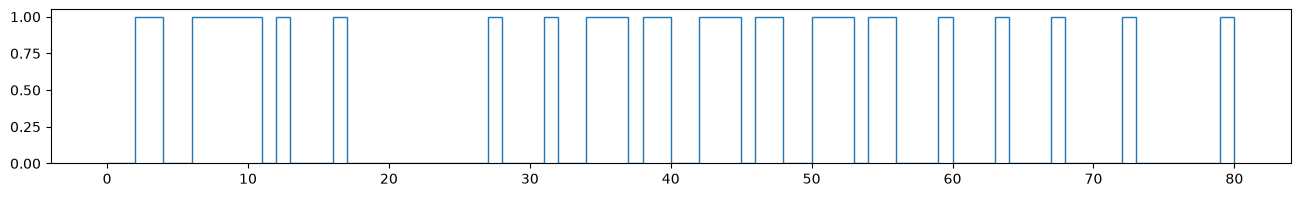

In [26]:
plt.figure(figsize=(16, 2))
plt.stairs(pronto_codes[0]['bits'])

In [27]:
len(_bits)

80

80 bits matches with the sequence length specified in the header and neatly specify 10 bytes of information.

## Bytes

In [28]:
for code in pronto_codes:
    code['bytes'] = []
    code['byteval'] = []
    for i in range(10):
        byte = "".join(str(b) for b in code['bits'][8*i:8*(i+1)])
        code['bytes'].append(byte)
        code['byteval'].append(int(byte, 2))

pronto_codes[0]['bytes']

['00110011',
 '11101000',
 '10000000',
 '00010001',
 '00111011',
 '00111011',
 '00111011',
 '00010001',
 '00010000',
 '10000001']

In [29]:
pronto_codes[0]['byteval']

[51, 232, 128, 17, 59, 59, 59, 17, 16, 129]

In [30]:
def get_code_by_label(label: str):
    """Helper function to retrieve a pronto code by its label"""
    for code in pronto_codes:
        if code['label'] == label:
            return code
    return None

In [31]:
from IPython.display import display, HTML

In [32]:
byte_comparision_table = ""
byte_comparision_table += "<table>"

byte_comparision_table += "<tr><th>Label</th>"

for column in range(10):
    byte_comparision_table += f"<th>Byte {column}</th><th>Val {column}</th>"

byte_comparision_table += "</tr>"

for row in pronto_codes:
    byte_comparision_table += f"<tr><td>{row['label']}</td>"
    for byte, val in zip(row['bytes'], row['byteval']):
        byte_comparision_table += f"<td>{byte}</td><td>{val}</td>"
    byte_comparision_table += "</tr>"

byte_comparision_table += "</table>"

display(HTML(byte_comparision_table))

Label,Byte 0,Val 0,Byte 1,Val 1,Byte 2,Val 2,Byte 3,Val 3,Byte 4,Val 4,Byte 5,Val 5,Byte 6,Val 6,Byte 7,Val 7,Byte 8,Val 8,Byte 9,Val 9
17-cool-fan-auto,00110011,51,11101000,232,10000000,128,00010001,17,00111011,59,00111011,59,00111011,59,00010001,17,00010000,16,10000001,129
17-cool-fan-high,00110011,51,00101000,40,10000000,128,00010001,17,00111011,59,00111011,59,00111011,59,00010001,17,00010000,16,01000001,65
17-cool-fan-low,00110011,51,10001000,136,10000000,128,00010001,17,00111011,59,00111011,59,00111011,59,00010001,17,00010000,16,11100001,225
17-cool-fan-medium,00110011,51,01001000,72,10000000,128,00010001,17,00111011,59,00111011,59,00111011,59,00010001,17,00010000,16,00100001,33
17-cool-hswing-off,00110011,51,00101000,40,10000000,128,00010001,17,00111011,59,00111011,59,00111011,59,00010001,17,00000000,0,01010001,81
17-cool-hswing-on,00110011,51,00101000,40,10000000,128,00010001,17,00111011,59,00111011,59,00111011,59,00010001,17,00010000,16,01000001,65
17-cool-turbo-off,00110011,51,00101000,40,10000000,128,00010001,17,00111011,59,00111011,59,00111011,59,00010001,17,00010000,16,01000001,65
17-cool-turbo-on,00110011,51,00101000,40,10100000,160,00010001,17,00111011,59,00111011,59,00111011,59,00010001,17,00010000,16,00100001,33
17-cool-vswing-off,00110011,51,00101000,40,10000000,128,00010001,17,00111011,59,00111011,59,00111011,59,00010001,17,00010000,16,01000001,65
17-cool-vswing-on,00110011,51,00101000,40,10000111,135,00010001,17,00111011,59,00111011,59,00111011,59,00010001,17,00010000,16,00111010,58


Byte 3 seems to directly map to the **Temperature** value. Byte 2 looks like its the **Power** state of the AC. Byte 9 is possibly the checksum.

## Diff

In [33]:
def diff(label1: str, label2: str):
    """Helper function to compare two pronto codes by their labels"""
    code1 = get_code_by_label(label1)
    code2 = get_code_by_label(label2)

    if not code1 or not code2:
        print(f"One or both labels not found: {label1}, {label2}")
        return

    diff_table = ""
    diff_table += "<table>"
    diff_table += f"<tr><th>Label</th><th>{label1}</th><th></th><th>{label2}</th><th></th></tr>"

    for i in range(10):
        byte1 = code1['bytes'][i]
        byte2 = code2['bytes'][i]
        val1 = code1['byteval'][i]
        val2 = code2['byteval'][i]

        if byte1 != byte2:
            diff_table += f"<tr><td>Byte {i}</td><td style='background-color: #ffcccc'>{byte1}</td><td style='background-color: #ffcccc'>{val1}</td><td style='background-color: #ffcccc'>{byte2}</td><td style='background-color: #ffcccc'>{val2}</td></tr>"
        else:
            diff_table += f"<tr><td>Byte {i}</td><td>{byte1}</td><td>{val1}</td><td>{byte2}</td><td>{val2}</td></tr>"

    diff_table += "</table>"

    display(HTML(diff_table))

In [34]:
diff("on", "off")

Label,on,,off,
Byte 0,00110011,51,00110011,51
Byte 1,00101000,40,00101000,40
Byte 2,10001000,136,00001000,8
Byte 3,00011000,24,00011000,24
Byte 4,00111011,59,00111011,59
Byte 5,00111011,59,00111011,59
Byte 6,00111011,59,00111011,59
Byte 7,00010001,17,00010001,17
Byte 8,00000000,0,00000000,0
Byte 9,01000010,66,11000010,194


Looks like the most-significant-bit (MSB) in Byte 2 represents the **Power** state of the AC. Not sure what the rest of the bits represent.

In [35]:
diff("on", "24-to-25-cool-fan-high")

Label,on,,24-to-25-cool-fan-high,
Byte 0,00110011,51,00110011,51
Byte 1,00101000,40,00101000,40
Byte 2,10001000,136,10001000,136
Byte 3,00011000,24,00011001,25
Byte 4,00111011,59,00111011,59
Byte 5,00111011,59,00111011,59
Byte 6,00111011,59,00111011,59
Byte 7,00010001,17,00010001,17
Byte 8,00000000,0,00000000,0
Byte 9,01000010,66,01000001,65


In [36]:
diff("25-to-26-cool-fan-high", "26-to-27-cool-fan-high")

Label,25-to-26-cool-fan-high,,26-to-27-cool-fan-high,
Byte 0,00110011,51,00110011,51
Byte 1,00101000,40,00101000,40
Byte 2,10001000,136,10001000,136
Byte 3,00011010,26,00011011,27
Byte 4,00111011,59,00111011,59
Byte 5,00111011,59,00111011,59
Byte 6,00111011,59,00111011,59
Byte 7,00010001,17,00010001,17
Byte 8,00000000,0,00000000,0
Byte 9,01000000,64,00111111,63


As noted before, byte 3 represents the temperature value

In [37]:
diff('on', 'on-28')

Label,on,,on-28,
Byte 0,00110011,51,00110011,51
Byte 1,00101000,40,00101000,40
Byte 2,10001000,136,10000000,128
Byte 3,00011000,24,00011100,28
Byte 4,00111011,59,00111011,59
Byte 5,00111011,59,00111011,59
Byte 6,00111011,59,00111011,59
Byte 7,00010001,17,00010001,17
Byte 8,00000000,0,00010000,16
Byte 9,01000010,66,00110110,54


In [38]:
diff('on-28', 'off-28')

Label,on-28,,off-28,
Byte 0,00110011,51,00110011,51
Byte 1,00101000,40,00101000,40
Byte 2,10000000,128,00000000,0
Byte 3,00011100,28,00011100,28
Byte 4,00111011,59,00111011,59
Byte 5,00111011,59,00111011,59
Byte 6,00111011,59,00111011,59
Byte 7,00010001,17,00010001,17
Byte 8,00010000,16,00010000,16
Byte 9,00110110,54,10110110,182


In [39]:
diff('off', 'off-17-cool')

Label,off,,off-17-cool,
Byte 0,00110011,51,00110011,51
Byte 1,00101000,40,00101000,40
Byte 2,00001000,8,00000000,0
Byte 3,00011000,24,00010001,17
Byte 4,00111011,59,00111011,59
Byte 5,00111011,59,00111011,59
Byte 6,00111011,59,00111011,59
Byte 7,00010001,17,00010001,17
Byte 8,00000000,0,00010001,17
Byte 9,11000010,194,11000000,192
